<a href="https://colab.research.google.com/github/dushimechri/linear_regression_model/blob/main/multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Identifying Key Clinical Factors Influencing Diabetes Progression Using Machine Learning
**objective:** Analyze and identify the most important clinical features that influence diabetes progression after one year.  
**Problem:** Analyzing and identifying the key clinical factors that influence diabetes disease progression one year after baseline using patient health metrics.  
**Dataset:** Scikit-learn Diabetes Dataset — includes data from 442 patients with 10 baseline clinical features and one continuous target variable representing disease progression  
**Source:** Originally from Bradley Efron, Trevor Hastie, Iain Johnstone and Robert Tibshirani (2004) *"Least Angle Regression"*, Annals of Statistics. Hosted in `sklearn.datasets`.

---

## 1. Setup & Data Loading

In [15]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [16]:
# Load dataset
data = load_diabetes()
X = data.data
y = data.target

# Convert to DataFrame for better readability
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

# Display first rows
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [17]:
# Basic info
df.info()

# Summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


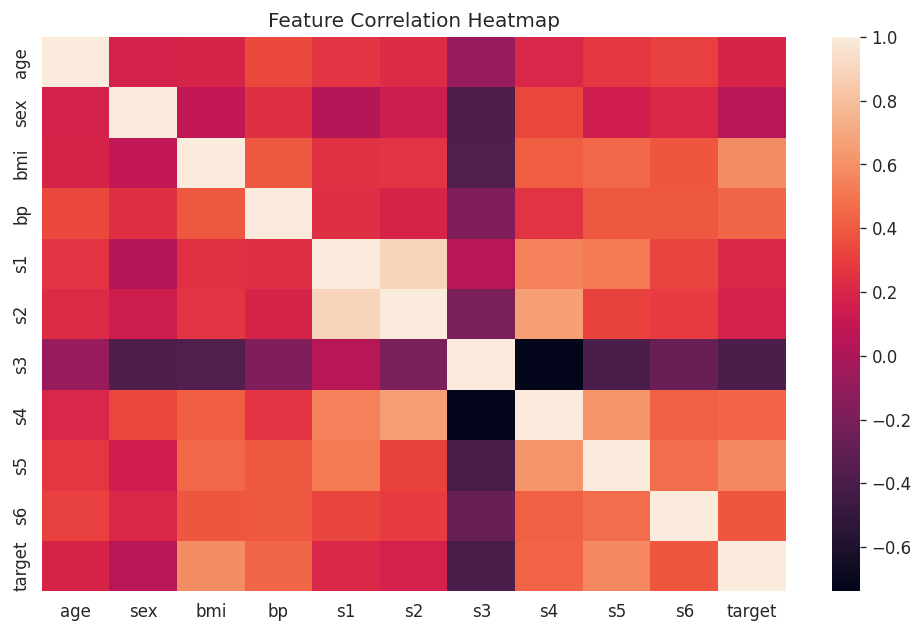

In [18]:
# Correlation matrix
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

---
## 2. Data Preparation: Train-Test Split

In [24]:
# Separate features and target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


---
## 3. Model Training

We train three models as required:
1. **Linear Regression** (with gradient descent via SGDRegressor)
2. **Decision Tree Regressor**
3. **Random Forest Regressor**

All models use scikit-learn.

In [20]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

---
## 4. Model Evaluation

In [21]:
# Predictions
y_pred = model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 2952.0105887640448
R² Score: 0.4428225673999313


---
## 5. Feature Importance Analysis

In [22]:
feature_names = data.feature_names
importance = model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

importance_df

,Feature,Importance
2,bmi,0.355469
8,s5,0.230957
3,bp,0.088408
9,s6,0.071329
0,age,0.058642
5,s2,0.057227
4,s1,0.052784
6,s3,0.051339
7,s4,0.024213
1,sex,0.009633


---
## Feature Importance Visualizat

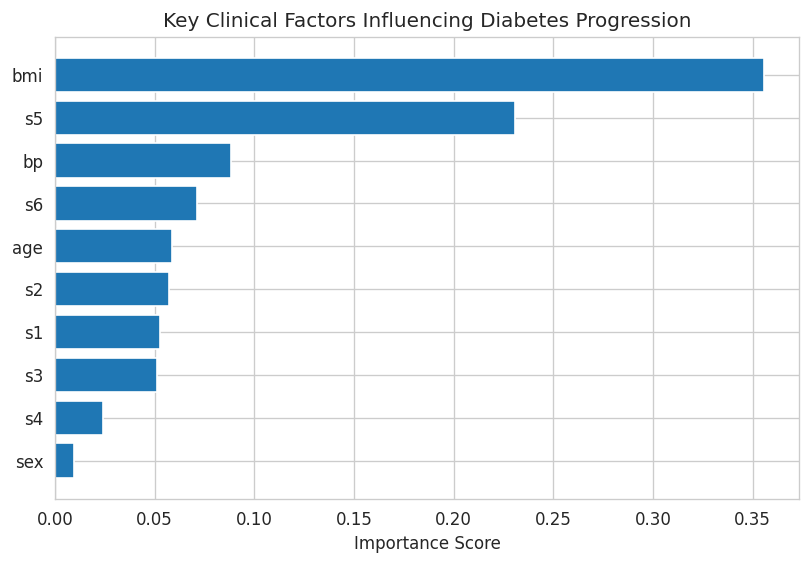

In [23]:
plt.figure(figsize=(8, 5))

plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Importance Score")
plt.title("Key Clinical Factors Influencing Diabetes Progression")

plt.gca().invert_yaxis()
plt.show()

## 6. Interpretation of Results


## Interpretation of Results

The feature importance analysis reveals that certain variables contribute more significantly
to diabetes progression than others.

Key observations:
- Body Mass Index (BMI) appears to be one of the most influential factors
- Blood pressure also plays a significant role
- Some blood serum measurements show strong impact

These findings suggest that both lifestyle-related and biological factors are critical in
understanding disease progression.

This insight can help healthcare providers prioritize monitoring and intervention strategies.